# 03 — Results Analysis

This notebook reads the outputs of `02_classify.ipynb` and produces:
1. **Article baseline** — reference results from the original publication (Table 2)
2. **Top results table** — mean ± std across splits, ranked by sensitivity and precision
3. **Best model selection** — per classifier, OG vs L2 vs raw
4. **Normalization impact** — L2 vs raw polynomial features, quantified per classifier
5. **Heatmaps** — sensitivity, precision, ROC-AUC for (representation × classifier)
6. **Efficiency curves** — metrics vs number of coefficients, L2 vs raw
7. **Baseline comparison** — OG XP and best transformed vs article baseline
8. **Statistical tests** — Wilcoxon signed-rank (10 splits, adequate power)
9. **Key takeaways**

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

HIGHLIGHT_GREEN = "background-color: #c6efce"
HIGHLIGHT_RED   = "background-color: #ffc7ce"

In [2]:
# ── Paths ──
EXPERIMENT_DIR = Path.cwd() if Path("results").exists() else Path("transformation_experiment")
RESULTS_DIR = EXPERIMENT_DIR / "results"

df_raw = pd.read_csv(RESULTS_DIR / "experiment_results.csv")
df_summary = pd.read_csv(RESULTS_DIR / "summary.csv")

print(f"Raw results: {len(df_raw)} rows")
print(f"Summary:     {len(df_summary)} rows")
print(f"Classifiers: {df_raw['classifier'].unique().tolist()}")
print(f"Representations: {df_raw['representation'].nunique()}")
print(f"Splits: {df_raw['split'].nunique()}")

Raw results: 2460 rows
Summary:     246 rows
Classifiers: ['LogisticRegression', 'SVM_RBF', 'RandomForest', 'XGBoost', 'GaussianNB', 'kNN']
Representations: 41
Splits: 10


In [3]:
# ── Helper columns ──
def parse_repr_name(name):
    """Extract basis, n_coeffs, and normalization from representation name."""
    if name == "og_xp_110":
        return "og_xp", 110, "L2"
    parts = name.split("_")
    norm = parts[-1]       # 'raw' or 'L2'
    n = int(parts[-2])     # number of coefficients
    basis = "_".join(parts[:-2])  # handles multi-word bases
    return basis, n, norm

for df in [df_raw, df_summary]:
    parsed = df["representation"].apply(parse_repr_name)
    df["basis"] = parsed.apply(lambda x: x[0])
    df["norm"] = parsed.apply(lambda x: x[2])
    df["is_og"] = df["representation"] == "og_xp_110"

classifiers = df_summary["classifier"].unique()
bases = ["chebyshev", "hermite", "laguerre", "legendre"]

print(f"Classifiers: {list(classifiers)}")
print(f"Bases: {bases}")
print(f"Normalizations: {df_summary['norm'].unique().tolist()}")

Classifiers: ['XGBoost', 'RandomForest', 'SVM_RBF', 'LogisticRegression', 'kNN', 'GaussianNB']
Bases: ['chebyshev', 'hermite', 'laguerre', 'legendre']
Normalizations: ['L2', 'raw']


## 1. Article baseline (Table 2)

Reference results from the original publication. The **CNN · Binary · Youden**
threshold is our primary comparison target.

In [4]:
article_baseline = pd.DataFrame([
    {"model": "SOM", "dataset": "Binary",     "threshold_method": "Youden", "threshold": 0.177, "sensitivity": 0.759, "specificity": 0.915, "precision": 0.649},
    {"model": "SOM", "dataset": "hot/He-rich", "threshold_method": "Youden", "threshold": 0.169, "sensitivity": 0.773, "specificity": 0.738, "precision": 0.714},
    {"model": "CNN", "dataset": "Binary",     "threshold_method": "Youden", "threshold": 0.295, "sensitivity": 0.878, "specificity": 0.965, "precision": 0.838},
    {"model": "CNN", "dataset": "hot/He-rich", "threshold_method": "Youden", "threshold": 0.745, "sensitivity": 0.818, "specificity": 0.985, "precision": 0.920},
    {"model": "SOM", "dataset": "Binary",     "threshold_method": "F1",     "threshold": 0.367, "sensitivity": 0.664, "specificity": 0.972, "precision": 0.832},
    {"model": "SOM", "dataset": "hot/He-rich", "threshold_method": "F1",     "threshold": 0.102, "sensitivity": 0.859, "specificity": 0.625, "precision": 0.660},
    {"model": "CNN", "dataset": "Binary",     "threshold_method": "F1",     "threshold": 0.745, "sensitivity": 0.818, "specificity": 0.985, "precision": 0.920},
    {"model": "CNN", "dataset": "hot/He-rich", "threshold_method": "F1",     "threshold": 0.525, "sensitivity": 0.847, "specificity": 0.908, "precision": 0.886},
])

art_cnn_youden = article_baseline[
    (article_baseline["model"] == "CNN")
    & (article_baseline["dataset"] == "Binary")
    & (article_baseline["threshold_method"] == "Youden")
].iloc[0]

ART_SENS = art_cnn_youden["sensitivity"]
ART_PREC = art_cnn_youden["precision"]
ART_SPEC = art_cnn_youden["specificity"]

print("Article baseline (Table 2):")
print(f"  Primary reference: CNN · Binary · Youden threshold")
print(f"  Sensitivity = {ART_SENS:.3f}   Precision = {ART_PREC:.3f}   Specificity = {ART_SPEC:.3f}")
print()

article_baseline.style.format({"threshold": "{:.3f}", "sensitivity": "{:.3f}",
                                "specificity": "{:.3f}", "precision": "{:.3f}"})

Article baseline (Table 2):
  Primary reference: CNN · Binary · Youden threshold
  Sensitivity = 0.878   Precision = 0.838   Specificity = 0.965



,model,dataset,threshold_method,threshold,sensitivity,specificity,precision
0,SOM,Binary,Youden,0.177,0.759,0.915,0.649
1,SOM,hot/He-rich,Youden,0.169,0.773,0.738,0.714
2,CNN,Binary,Youden,0.295,0.878,0.965,0.838
3,CNN,hot/He-rich,Youden,0.745,0.818,0.985,0.920
4,SOM,Binary,F1,0.367,0.664,0.972,0.832
5,SOM,hot/He-rich,F1,0.102,0.859,0.625,0.660
6,CNN,Binary,F1,0.745,0.818,0.985,0.920
7,CNN,hot/He-rich,F1,0.525,0.847,0.908,0.886


## 2. Top results — ranked by Sensitivity & Precision

In [5]:
display_cols = [
    "representation", "classifier", "n_features", "norm",
    "sensitivity_mean", "sensitivity_std",
    "precision_mean", "precision_std",
    "specificity_mean",
    "roc_auc_mean", "f1_mean",
]

fmt = {c: "{:.4f}" for c in display_cols if c.endswith(("_mean", "_std"))}

top = df_summary.sort_values(
    ["sensitivity_mean", "precision_mean"], ascending=[False, False]
).head(20)

print("Top 20 configurations (ranked by Sensitivity, then Precision):")
(
    top[display_cols]
    .reset_index(drop=True)
    .style
    .format(fmt)
    .background_gradient(subset=["sensitivity_mean", "precision_mean"], cmap="YlGn")
    .background_gradient(subset=["roc_auc_mean"], cmap="Blues")
)

Top 20 configurations (ranked by Sensitivity, then Precision):


,representation,classifier,n_features,norm,sensitivity_mean,sensitivity_std,precision_mean,precision_std,specificity_mean,roc_auc_mean,f1_mean
0,legendre_10_raw,RandomForest,10,raw,1.0000,0.0000,0.1989,0.0000,0.0000,0.5000,0.3319
1,chebyshev_10_raw,RandomForest,10,raw,1.0000,0.0000,0.1989,0.0000,0.0000,0.5000,0.3319
2,hermite_10_raw,RandomForest,10,raw,1.0000,0.0000,0.1989,0.0000,0.0000,0.5000,0.3319
3,chebyshev_30_raw,RandomForest,30,raw,1.0000,0.0000,0.1989,0.0000,0.0000,0.5000,0.3319
4,legendre_50_raw,RandomForest,50,raw,1.0000,0.0000,0.1989,0.0000,0.0000,0.5000,0.3319
5,chebyshev_20_raw,RandomForest,20,raw,1.0000,0.0000,0.1989,0.0000,0.0000,0.5000,0.3319
6,legendre_20_raw,RandomForest,20,raw,1.0000,0.0000,0.1989,0.0000,0.0000,0.5000,0.3319
7,chebyshev_40_raw,RandomForest,40,raw,1.0000,0.0000,0.1989,0.0000,0.0000,0.5000,0.3319
8,legendre_40_raw,RandomForest,40,raw,1.0000,0.0000,0.1989,0.0000,0.0000,0.5000,0.3319
9,legendre_30_raw,RandomForest,30,raw,1.0000,0.0000,0.1989,0.0000,0.0000,0.5000,0.3319


## 3. Best model selection

Select the best configuration per classifier by sensitivity (primary)
and precision (secondary). Filter out degenerate models.

In [18]:
fmt4 = lambda cols: {c: "{:.4f}" for c in cols}
metric_cols_show = ["sensitivity_mean", "sensitivity_std", "precision_mean", "precision_std",
                    "specificity_mean", "roc_auc_mean", "f1_mean"]
show_cols = ["representation", "classifier", "n_features", "norm"] + metric_cols_show

MIN_PRECISION = 0.30
df_viable = df_summary[df_summary["precision_mean"] >= MIN_PRECISION].copy()
n_filtered = len(df_summary) - len(df_viable)
print(f"Filtering out {n_filtered} configs with precision < {MIN_PRECISION} (degenerate classifiers)\n")

print("=" * 100)
print("Best by SENSITIVITY (primary), Precision (secondary):")
print("=" * 100)
best_sens = (
    df_viable
    .sort_values(["sensitivity_mean", "precision_mean"], ascending=[False, False])
    .drop_duplicates(subset=["classifier"], keep="first")
    .sort_values("sensitivity_mean", ascending=False)
)
display(
    best_sens[show_cols].reset_index(drop=True)
    .style.format(fmt4(metric_cols_show))
    .background_gradient(subset=["sensitivity_mean"], cmap="YlGn")
    .background_gradient(subset=["precision_mean"], cmap="YlOrRd")
)

print()
print("=" * 100)
print("Best OVERALL (highest sensitivity + precision sum):")
print("=" * 100)
df_viable["sens_prec_sum"] = df_viable["sensitivity_mean"] + df_viable["precision_mean"]
best_combined = df_viable.sort_values("sens_prec_sum", ascending=False).head(20)
display(
    best_combined[show_cols].reset_index(drop=True)
    .style.format(fmt4(metric_cols_show))
    .background_gradient(subset=["sensitivity_mean"], cmap="YlGn")
    .background_gradient(subset=["precision_mean"], cmap="YlOrRd")
)

Filtering out 113 configs with precision < 0.3 (degenerate classifiers)

Best by SENSITIVITY (primary), Precision (secondary):


,representation,classifier,n_features,norm,sensitivity_mean,sensitivity_std,precision_mean,precision_std,specificity_mean,roc_auc_mean,f1_mean
0,og_xp_110,XGBoost,110,L2,0.8527,0.0250,0.8309,0.0388,0.9563,0.9527,0.8409
1,og_xp_110,RandomForest,110,L2,0.8473,0.0268,0.8195,0.0317,0.9532,0.9495,0.8326
2,chebyshev_30_L2,SVM_RBF,30,L2,0.8473,0.0199,0.7543,0.0387,0.9308,0.9310,0.7976
3,chebyshev_20_L2,LogisticRegression,20,L2,0.8402,0.0353,0.8066,0.0383,0.9494,0.9168,0.8223
4,og_xp_110,kNN,110,L2,0.7920,0.0332,0.6522,0.0358,0.8942,0.9028,0.7145
5,legendre_40_L2,GaussianNB,40,L2,0.7438,0.0801,0.3961,0.0316,0.7142,0.7946,0.5142



Best OVERALL (highest sensitivity + precision sum):


,representation,classifier,n_features,norm,sensitivity_mean,sensitivity_std,precision_mean,precision_std,specificity_mean,roc_auc_mean,f1_mean
0,og_xp_110,XGBoost,110,L2,0.8527,0.0250,0.8309,0.0388,0.9563,0.9527,0.8409
1,og_xp_110,RandomForest,110,L2,0.8473,0.0268,0.8195,0.0317,0.9532,0.9495,0.8326
2,chebyshev_10_L2,LogisticRegression,10,L2,0.8348,0.0332,0.8319,0.0280,0.9579,0.9215,0.8329
3,legendre_10_L2,LogisticRegression,10,L2,0.8357,0.0316,0.8260,0.0300,0.9561,0.9201,0.8305
4,legendre_20_L2,LogisticRegression,20,L2,0.8384,0.0343,0.8123,0.0117,0.9519,0.9194,0.8249
5,legendre_30_L2,LogisticRegression,30,L2,0.8366,0.0266,0.8107,0.0427,0.9510,0.9242,0.8230
6,chebyshev_20_L2,LogisticRegression,20,L2,0.8402,0.0353,0.8066,0.0383,0.9494,0.9168,0.8223
7,chebyshev_30_L2,LogisticRegression,30,L2,0.8348,0.0318,0.8072,0.0240,0.9503,0.9235,0.8204
8,og_xp_110,LogisticRegression,110,L2,0.8366,0.0198,0.8030,0.0258,0.9488,0.9282,0.8191
9,legendre_10_L2,SVM_RBF,10,L2,0.8339,0.0398,0.8051,0.0308,0.9494,0.9362,0.8184


## 4. Normalization impact — L2 vs Raw polynomial features

Quantify how L2 normalization affects classification performance.
L2 normalization removes amplitude information, which polynomial coefficients
encode (unlike OG XP coefficients which were designed for L2 normalization).

In [7]:
poly_only = df_summary[~df_summary["is_og"]].copy()

# Compare L2 vs raw for each (basis, n_features, classifier)
poly_only["base_key"] = poly_only["basis"] + "_" + poly_only["n_features"].astype(str)

l2_results = poly_only[poly_only["norm"] == "L2"].set_index(["base_key", "classifier"])
raw_results = poly_only[poly_only["norm"] == "raw"].set_index(["base_key", "classifier"])

common_idx = l2_results.index.intersection(raw_results.index)

norm_comparison = []
for key in common_idx:
    l2_row = l2_results.loc[key]
    raw_row = raw_results.loc[key]
    norm_comparison.append({
        "representation": key[0],
        "classifier": key[1],
        "sens_L2": l2_row["sensitivity_mean"],
        "sens_raw": raw_row["sensitivity_mean"],
        "sens_delta": raw_row["sensitivity_mean"] - l2_row["sensitivity_mean"],
        "prec_L2": l2_row["precision_mean"],
        "prec_raw": raw_row["precision_mean"],
        "prec_delta": raw_row["precision_mean"] - l2_row["precision_mean"],
        "auc_L2": l2_row["roc_auc_mean"],
        "auc_raw": raw_row["roc_auc_mean"],
        "auc_delta": raw_row["roc_auc_mean"] - l2_row["roc_auc_mean"],
    })

df_norm = pd.DataFrame(norm_comparison)

print("Mean impact of removing L2 normalization (raw - L2), by classifier:")
print("Positive delta = raw is better\n")
norm_by_clf = df_norm.groupby("classifier")[["sens_delta", "prec_delta", "auc_delta"]].mean()
norm_by_clf.columns = ["Sensitivity Δ", "Precision Δ", "ROC-AUC Δ"]
display(norm_by_clf.style.format("{:+.4f}").background_gradient(cmap="RdYlGn", axis=None))

print("\nMean impact by basis:")
norm_by_basis = df_norm.groupby("representation")[["sens_delta", "prec_delta", "auc_delta"]].mean()
norm_by_basis.columns = ["Sensitivity Δ", "Precision Δ", "ROC-AUC Δ"]
display(norm_by_basis.style.format("{:+.4f}").background_gradient(cmap="RdYlGn", axis=None))

df_norm.to_csv(RESULTS_DIR / "normalization_comparison.csv", index=False)

Mean impact of removing L2 normalization (raw - L2), by classifier:
Positive delta = raw is better



,Sensitivity Δ,Precision Δ,ROC-AUC Δ
classifier,,,
GaussianNB,+0.3564,-0.1559,-0.1484
LogisticRegression,+0.0332,-0.2347,-0.0721
RandomForest,+0.3035,-0.3003,-0.2772
SVM_RBF,+0.0712,-0.1282,-0.0282
XGBoost,-0.0265,-0.1698,-0.0701
kNN,-0.0117,-0.1175,-0.0641



Mean impact by basis:


,Sensitivity Δ,Precision Δ,ROC-AUC Δ
representation,,,
chebyshev_10,-0.0305,-0.3447,-0.2049
chebyshev_20,+0.0030,-0.3105,-0.1878
chebyshev_30,-0.0046,-0.2943,-0.1845
chebyshev_40,+0.0152,-0.2771,-0.1786
chebyshev_50,+0.0158,-0.2706,-0.1815
hermite_10,+0.2567,-0.1476,-0.0503
hermite_20,+0.2481,-0.0386,-0.0073
hermite_30,+0.2256,-0.0162,+0.0076
hermite_40,+0.1682,-0.0241,-0.0210


## 5. Heatmaps — Sensitivity, Precision, ROC-AUC

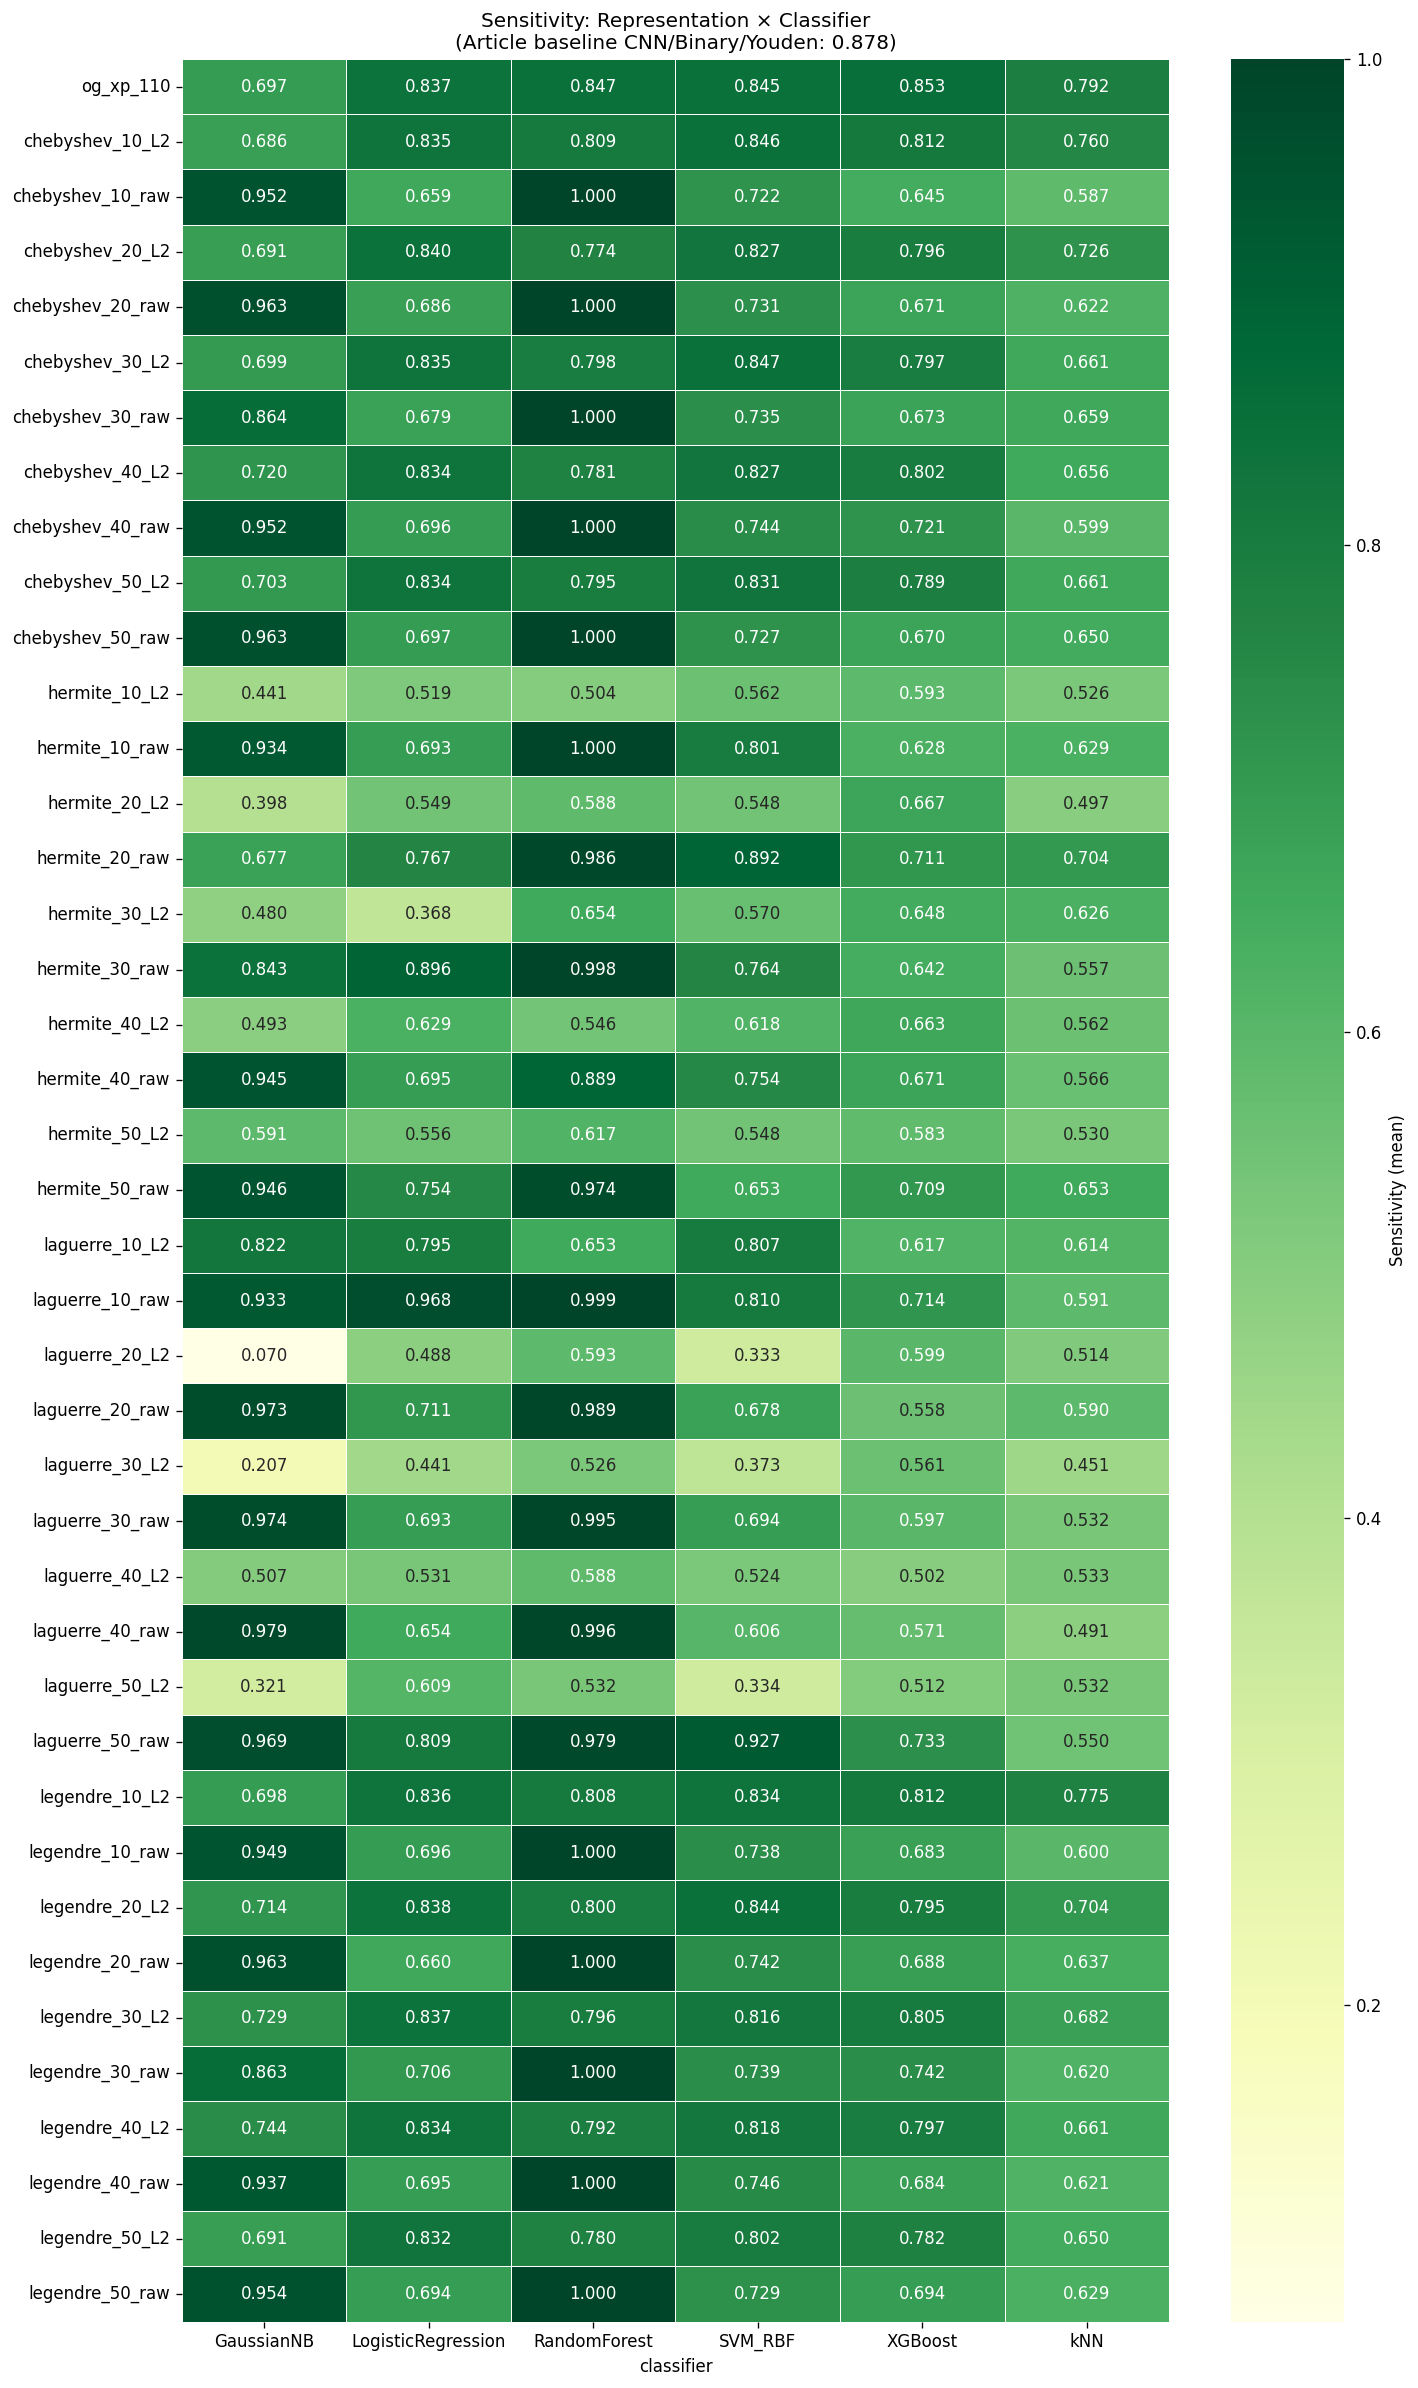

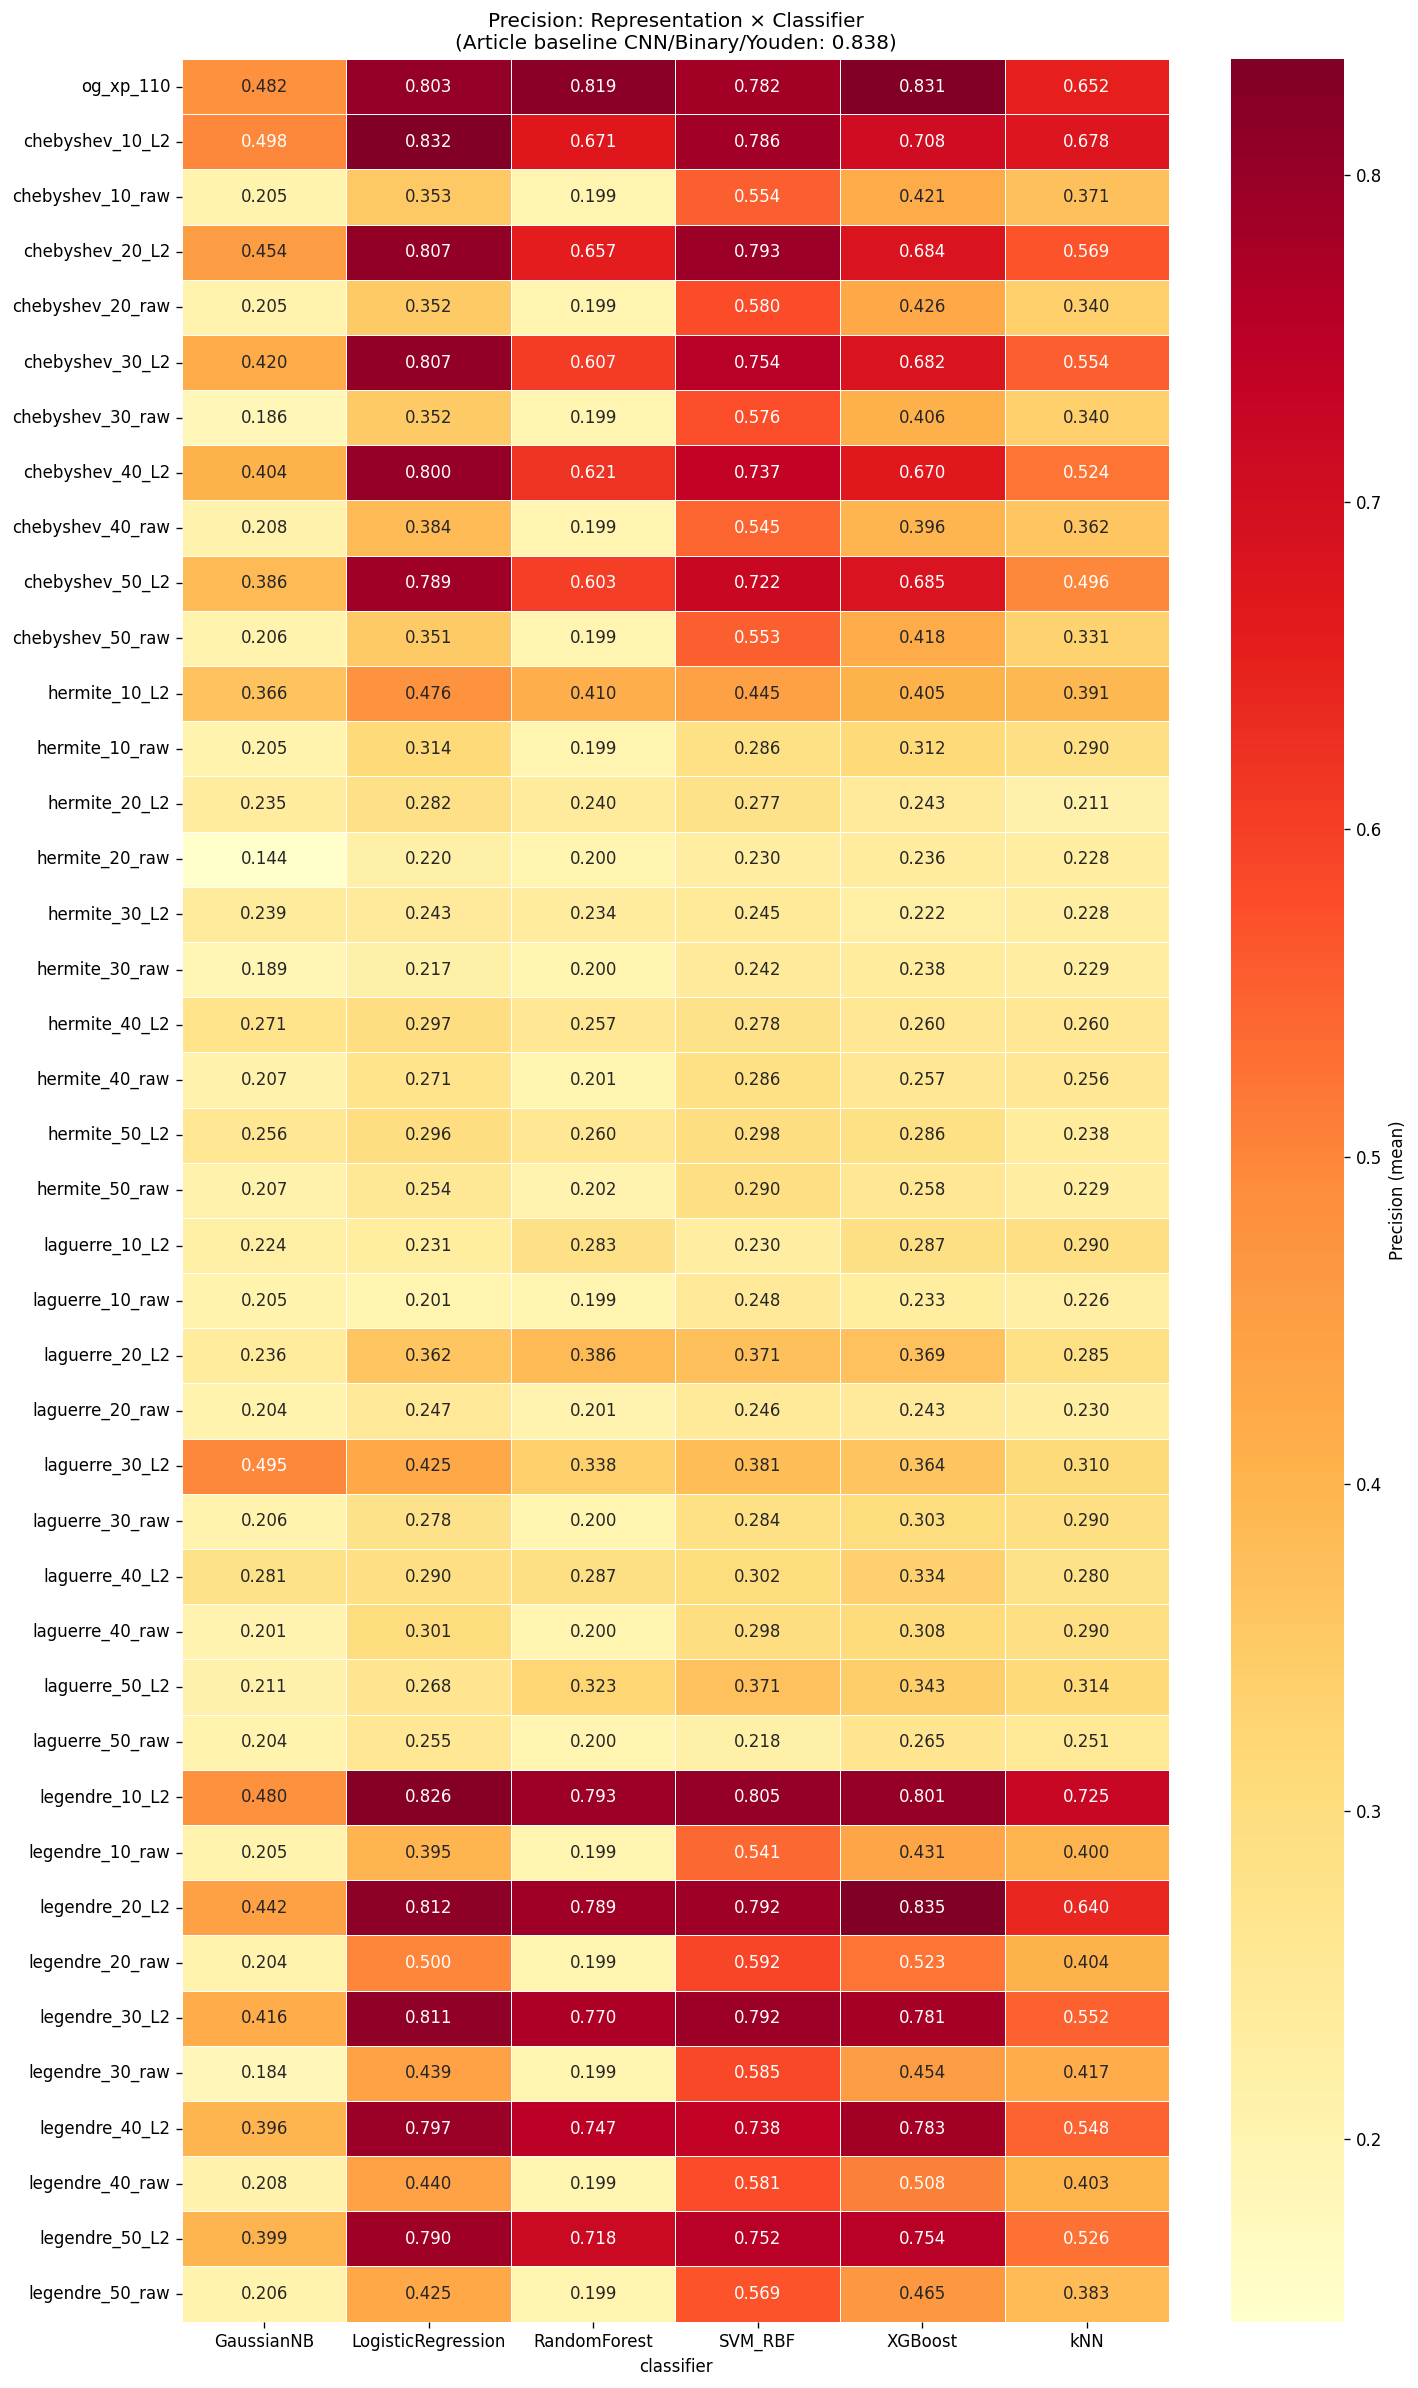

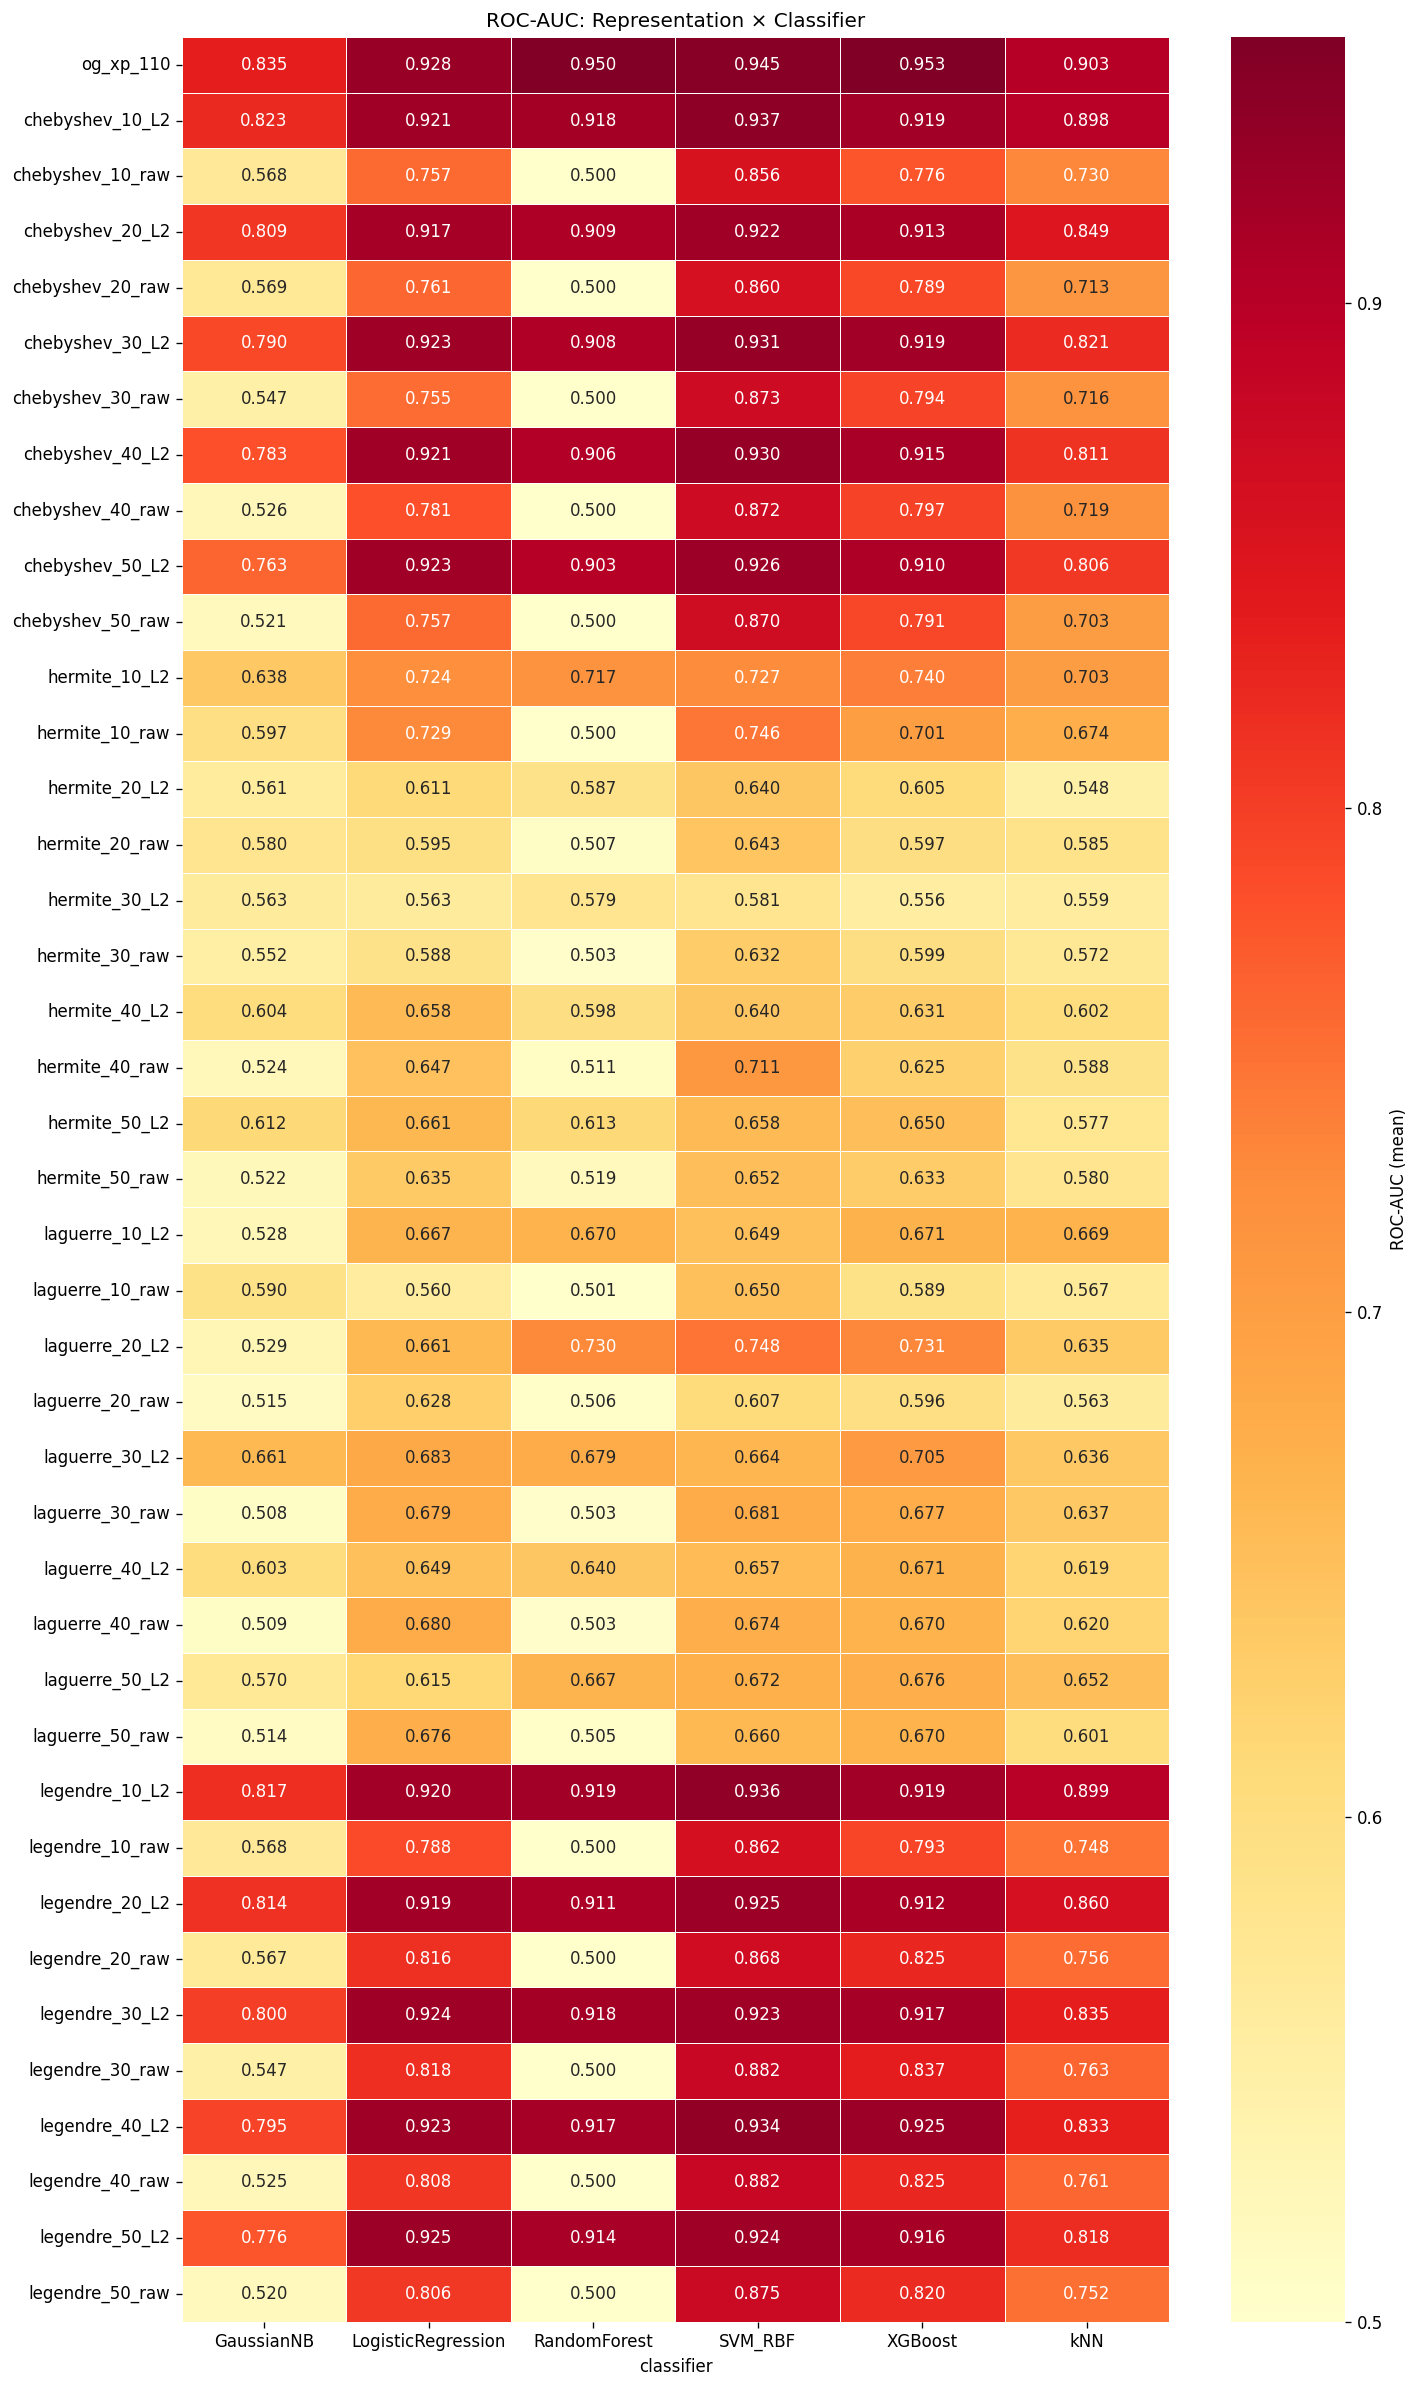

In [8]:
def sort_key(name):
    if name == "og_xp_110":
        return ("0_og", 0, "A")
    parts = name.split("_")
    norm = parts[-1]
    n = int(parts[-2])
    basis = "_".join(parts[:-2])
    return (basis, n, norm)

for metric, label, cmap, art_val in [
    ("sensitivity_mean", "Sensitivity", "YlGn", ART_SENS),
    ("precision_mean",   "Precision",   "YlOrRd", ART_PREC),
    ("roc_auc_mean",     "ROC-AUC",     "YlOrRd", None),
]:
    pivot = df_summary.pivot_table(
        index="representation", columns="classifier", values=metric
    )
    row_order = sorted(pivot.index, key=sort_key)
    pivot = pivot.loc[row_order]

    fig, ax = plt.subplots(figsize=(12, 20))
    sns.heatmap(
        pivot, annot=True, fmt=".3f", cmap=cmap, linewidths=0.5,
        cbar_kws={"label": f"{label} (mean)"},
        ax=ax,
    )
    title = f"{label}: Representation × Classifier"
    if art_val is not None:
        title += f"\n(Article baseline CNN/Binary/Youden: {art_val:.3f})"
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("")
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / f"heatmap_{label.lower().replace('-','_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## 6. Efficiency curves — Metrics vs number of coefficients

Separate lines for L2-normalized and raw polynomial features.

In [ ]:
from scipy import stats as _stats

N_SPLITS = 10  # number of CV splits in broad experiment
_t_crit = _stats.t.ppf(0.975, N_SPLITS - 1)

baseline_row = df_summary[df_summary["representation"] == "og_xp_110"].set_index("classifier")
n_clf = len(classifiers)
n_cols = 1
n_rows = (n_clf + n_cols - 1) // n_cols

for metric, metric_label, art_val in [
    ("sensitivity", "Sensitivity", ART_SENS),
    ("precision",   "Precision",   ART_PREC),
    ("roc_auc",     "ROC-AUC",     None),
]:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharey=True)
    axes_flat = axes.ravel() if n_clf > 1 else [axes]
    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"

    for idx, clf_name in enumerate(classifiers):
        ax = axes_flat[idx]
        bl = baseline_row.loc[clf_name, mean_col] if clf_name in baseline_row.index else 0
        ax.axhline(bl, color="black", ls="--", lw=1.5,
                   label=f"OG XP 110 ({bl:.3f})")

        if art_val is not None:
            ax.axhline(art_val, color="red", ls=":", lw=1.5,
                       label=f"Article CNN ({art_val:.3f})")

        for basis in bases:
            for norm, ls in [("raw", "-"), ("L2", "--")]:
                subset = df_summary[
                    (df_summary["basis"] == basis)
                    & (df_summary["classifier"] == clf_name)
                    & (df_summary["norm"] == norm)
                ].sort_values("n_features")
                if len(subset) == 0:
                    continue
                ci_half = _t_crit * subset[std_col] / np.sqrt(N_SPLITS)
                ax.errorbar(
                    subset["n_features"], subset[mean_col], yerr=ci_half,
                    marker="o", capsize=3, ls=ls,
                    label=f"{basis.capitalize()} ({norm})",
                )

        ax.set_title(clf_name)
        ax.set_xlabel("Number of coefficients")
        ax.set_ylabel(f"{metric_label} (mean ± 95% CI)")
        ax.legend(fontsize=6, loc="lower right")
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for idx in range(n_clf, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    fig.suptitle(f"{metric_label}: polynomial transformations vs baselines", fontsize=13)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / f"efficiency_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Comparison with article baseline

Compare against the strongest article baseline: **CNN · Binary · Youden threshold**.
Show OG XP results and best transformed results per classifier.

In [10]:
def delta_color(val):
    if val > 0:
        return HIGHLIGHT_GREEN
    elif val < 0:
        return HIGHLIGHT_RED
    return ""

def build_comparison(subset, label):
    rows = []
    for _, r in subset.iterrows():
        rows.append({
            "representation": r["representation"],
            "classifier": r["classifier"],
            "n_features": r["n_features"],
            "norm": r.get("norm", "L2"),
            "sensitivity": r["sensitivity_mean"],
            "sens_vs_article": r["sensitivity_mean"] - ART_SENS,
            "precision": r["precision_mean"],
            "prec_vs_article": r["precision_mean"] - ART_PREC,
            "specificity": r["specificity_mean"],
            "roc_auc": r["roc_auc_mean"],
            "f1": r["f1_mean"],
        })
    comp = pd.DataFrame(rows)
    if len(comp) == 0:
        print(f"  No results for {label}.")
        return comp
    return comp.sort_values(["sensitivity", "precision"], ascending=[False, False]).reset_index(drop=True)

In [11]:
delta_cols = ["sens_vs_article", "prec_vs_article"]
value_cols = ["sensitivity", "precision", "specificity", "roc_auc", "f1"]
fmt_comp = {c: "{:.4f}" for c in value_cols + delta_cols}
fmt_comp.update({c: "{:+.4f}" for c in delta_cols})

# OG XP vs article
og_results = df_summary[df_summary["representation"] == "og_xp_110"]
comp_og = build_comparison(og_results, "OG XP 110")

print(f"Article baseline (CNN/Binary/Youden): Sensitivity={ART_SENS:.3f}  Precision={ART_PREC:.3f}\n")
print("OG XP 110 vs article:")
display(
    comp_og.style
    .format(fmt_comp)
    .map(delta_color, subset=delta_cols)
)

# Best transformed per classifier
trans_viable = df_viable[df_viable["representation"] != "og_xp_110"]
best_trans_per_clf = (
    trans_viable
    .sort_values(["sensitivity_mean", "precision_mean"], ascending=[False, False])
    .drop_duplicates(subset=["classifier"], keep="first")
)

comp_trans = build_comparison(best_trans_per_clf, "Best transformed")

print("\nBest TRANSFORMED representation per classifier vs article:")
display(
    comp_trans.style
    .format(fmt_comp)
    .map(delta_color, subset=delta_cols)
)

Article baseline (CNN/Binary/Youden): Sensitivity=0.878  Precision=0.838

OG XP 110 vs article:


,representation,classifier,n_features,norm,sensitivity,sens_vs_article,precision,prec_vs_article,specificity,roc_auc,f1
0,og_xp_110,XGBoost,110,L2,0.8527,-0.0253,0.8309,-0.0071,0.9563,0.9527,0.8409
1,og_xp_110,RandomForest,110,L2,0.8473,-0.0307,0.8195,-0.0185,0.9532,0.9495,0.8326
2,og_xp_110,SVM_RBF,110,L2,0.8446,-0.0334,0.7821,-0.0559,0.9404,0.9450,0.8111
3,og_xp_110,LogisticRegression,110,L2,0.8366,-0.0414,0.8030,-0.0350,0.9488,0.9282,0.8191
4,og_xp_110,kNN,110,L2,0.7920,-0.0860,0.6522,-0.1858,0.8942,0.9028,0.7145
5,og_xp_110,GaussianNB,110,L2,0.6973,-0.1807,0.4815,-0.3565,0.8124,0.8347,0.5686



Best TRANSFORMED representation per classifier vs article:


,representation,classifier,n_features,norm,sensitivity,sens_vs_article,precision,prec_vs_article,specificity,roc_auc,f1
0,chebyshev_30_L2,SVM_RBF,30,L2,0.8473,-0.0307,0.7543,-0.0837,0.9308,0.9310,0.7976
1,chebyshev_20_L2,LogisticRegression,20,L2,0.8402,-0.0378,0.8066,-0.0314,0.9494,0.9168,0.8223
2,chebyshev_10_L2,XGBoost,10,L2,0.8125,-0.0655,0.7077,-0.1303,0.9153,0.9193,0.7551
3,chebyshev_10_L2,RandomForest,10,L2,0.8089,-0.0691,0.6714,-0.1666,0.8996,0.9179,0.7317
4,legendre_10_L2,kNN,10,L2,0.7750,-0.1030,0.7249,-0.1131,0.9266,0.8988,0.7485
5,legendre_40_L2,GaussianNB,40,L2,0.7438,-0.1342,0.3961,-0.4419,0.7142,0.7946,0.5142


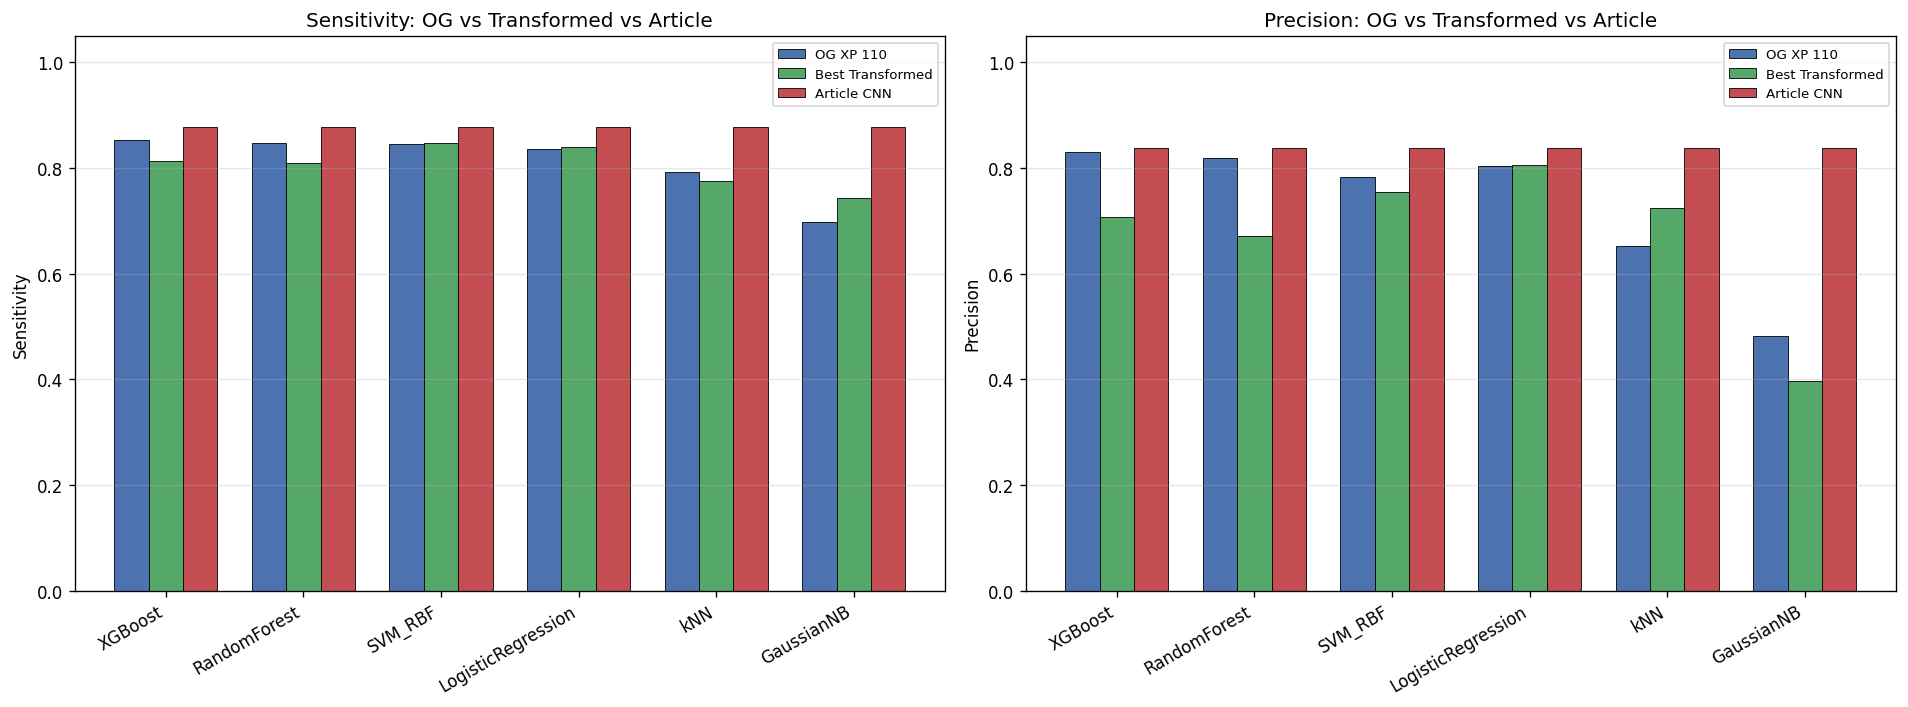

In [12]:
# ── Visual comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (metric, label, art_val) in zip(axes, [
    ("sensitivity", "Sensitivity", ART_SENS),
    ("precision", "Precision", ART_PREC),
]):
    og_vals = comp_og.set_index("classifier")[metric]
    trans_vals = comp_trans.set_index("classifier")[metric] if len(comp_trans) > 0 else pd.Series(dtype=float)

    present_clfs = [c for c in classifiers if c in og_vals.index or c in trans_vals.index]
    x = np.arange(len(present_clfs))
    width = 0.25

    ax.bar(x - width, [og_vals.get(c, 0) for c in present_clfs],
           width, label="OG XP 110", color="#4c72b0", edgecolor="black", linewidth=0.5)
    ax.bar(x, [trans_vals.get(c, 0) for c in present_clfs],
           width, label="Best Transformed", color="#55a868", edgecolor="black", linewidth=0.5)
    ax.bar(x + width, [art_val] * len(present_clfs),
           width, label="Article CNN", color="#c44e52", edgecolor="black", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(present_clfs, rotation=30, ha="right")
    ax.set_ylabel(label)
    ax.set_title(f"{label}: OG vs Transformed vs Article")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
fig.savefig(RESULTS_DIR / "comparison_vs_article.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Statistical significance — Wilcoxon signed-rank test

With 10 splits the test achieves minimum p ≈ 0.002 (vs 0.0625 with 5 splits).
For each classifier, compare per-split metrics of the best polynomial
representation against the OG XP baseline.

In [13]:
significance_results = []

for metric, metric_label in [("sensitivity", "Sensitivity"), ("precision", "Precision"),
                              ("roc_auc", "ROC-AUC")]:
    for clf_name in classifiers:
        bl_scores = (
            df_raw[(df_raw["representation"] == "og_xp_110") & (df_raw["classifier"] == clf_name)]
            .sort_values("split")[metric].values
        )

        # Find best polynomial representation (by mean of this metric)
        poly_summary = df_summary[
            (df_summary["classifier"] == clf_name)
            & (~df_summary["is_og"])
        ].sort_values(f"{metric}_mean", ascending=False)

        if len(poly_summary) == 0:
            continue

        best_repr = poly_summary.iloc[0]["representation"]
        best_scores = (
            df_raw[(df_raw["representation"] == best_repr) & (df_raw["classifier"] == clf_name)]
            .sort_values("split")[metric].values
        )

        if len(bl_scores) != len(best_scores) or len(bl_scores) < 5:
            continue

        diff = best_scores - bl_scores
        if np.all(diff == 0):
            p_value = 1.0
        else:
            try:
                _, p_value = wilcoxon(best_scores, bl_scores, alternative="two-sided")
            except ValueError:
                p_value = np.nan

        significance_results.append({
            "metric": metric_label,
            "classifier": clf_name,
            "baseline_og_mean": bl_scores.mean(),
            "best_poly": best_repr,
            "best_poly_mean": best_scores.mean(),
            "delta": best_scores.mean() - bl_scores.mean(),
            "p_value": p_value,
            "significant_005": p_value < 0.05 if not np.isnan(p_value) else False,
            "significant_001": p_value < 0.01 if not np.isnan(p_value) else False,
        })

df_sig = pd.DataFrame(significance_results)
df_sig.to_csv(RESULTS_DIR / "significance_tests.csv", index=False)

print("Wilcoxon signed-rank test: best polynomial vs OG XP baseline")
print(f"Number of paired observations (splits): {df_raw['split'].nunique()}\n")
df_sig.style.format({
    "baseline_og_mean": "{:.4f}",
    "best_poly_mean": "{:.4f}",
    "delta": "{:+.4f}",
    "p_value": "{:.4f}",
}).apply(
    lambda row: [HIGHLIGHT_GREEN if row["significant_005"] else "" for _ in row],
    axis=1,
)

Wilcoxon signed-rank test: best polynomial vs OG XP baseline
Number of paired observations (splits): 10



,metric,classifier,baseline_og_mean,best_poly,best_poly_mean,delta,p_value,significant_005,significant_001
0,Sensitivity,XGBoost,0.8527,chebyshev_10_L2,0.8125,-0.0402,0.0078,True,True
1,Sensitivity,RandomForest,0.8473,chebyshev_50_raw,1.0000,+0.1527,0.0020,True,True
2,Sensitivity,SVM_RBF,0.8446,laguerre_50_raw,0.9268,+0.0821,0.1055,False,False
3,Sensitivity,LogisticRegression,0.8366,laguerre_10_raw,0.9679,+0.1313,0.0020,True,True
4,Sensitivity,kNN,0.7920,legendre_10_L2,0.7750,-0.0170,0.1836,False,False
5,Sensitivity,GaussianNB,0.6973,laguerre_40_raw,0.9795,+0.2821,0.0020,True,True
6,Precision,XGBoost,0.8309,legendre_20_L2,0.8354,+0.0045,0.6523,False,False
7,Precision,RandomForest,0.8195,legendre_10_L2,0.7934,-0.0260,0.4922,False,False
8,Precision,SVM_RBF,0.7821,legendre_10_L2,0.8051,+0.0230,0.4922,False,False
9,Precision,LogisticRegression,0.8030,chebyshev_10_L2,0.8319,+0.0288,0.0059,True,True


## 9. Key takeaways

In [14]:
best_overall = df_viable.copy()
best_overall["_score"] = best_overall["sensitivity_mean"] + best_overall["precision_mean"]
best_overall = best_overall.sort_values("_score", ascending=False).iloc[0]

og_best = df_summary[
    df_summary["representation"] == "og_xp_110"
].sort_values("sensitivity_mean", ascending=False).iloc[0]

trans_best = df_viable[
    df_viable["representation"] != "og_xp_110"
].sort_values(["sensitivity_mean", "precision_mean"], ascending=[False, False])
trans_best_row = trans_best.iloc[0] if len(trans_best) > 0 else None

print("KEY TAKEAWAYS")
print("=" * 80)
print()
print("Article baseline (CNN / Binary / Youden):")
print(f"  Sensitivity = {ART_SENS:.3f}    Precision = {ART_PREC:.3f}    Specificity = {ART_SPEC:.3f}")
print()

print("-" * 80)
print("Our best with OG XP coefficients (110 features):")
print(f"  Classifier: {og_best['classifier']}")
print(f"  Sensitivity = {og_best['sensitivity_mean']:.4f} +/- {og_best['sensitivity_std']:.4f}  "
      f"(vs article: {og_best['sensitivity_mean'] - ART_SENS:+.4f})")
print(f"  Precision   = {og_best['precision_mean']:.4f} +/- {og_best['precision_std']:.4f}  "
      f"(vs article: {og_best['precision_mean'] - ART_PREC:+.4f})")
print(f"  ROC-AUC     = {og_best['roc_auc_mean']:.4f}")
print()

print("-" * 80)
if trans_best_row is not None:
    print("Our best with TRANSFORMED coefficients:")
    print(f"  {trans_best_row['representation']} + {trans_best_row['classifier']}  "
          f"({trans_best_row['n_features']:.0f} features, norm={trans_best_row['norm']})")
    print(f"  Sensitivity = {trans_best_row['sensitivity_mean']:.4f} +/- {trans_best_row['sensitivity_std']:.4f}  "
          f"(vs article: {trans_best_row['sensitivity_mean'] - ART_SENS:+.4f})")
    print(f"  Precision   = {trans_best_row['precision_mean']:.4f} +/- {trans_best_row['precision_std']:.4f}  "
          f"(vs article: {trans_best_row['precision_mean'] - ART_PREC:+.4f})")
    print(f"  ROC-AUC     = {trans_best_row['roc_auc_mean']:.4f}")
else:
    print("No viable transformed configuration found.")
print()

# Normalization verdict
print("-" * 80)
print("Normalization impact (mean raw - L2 delta across all configurations):")
if len(df_norm) > 0:
    mean_deltas = df_norm[["sens_delta", "prec_delta", "auc_delta"]].mean()
    print(f"  Sensitivity: {mean_deltas['sens_delta']:+.4f}")
    print(f"  Precision:   {mean_deltas['prec_delta']:+.4f}")
    print(f"  ROC-AUC:     {mean_deltas['auc_delta']:+.4f}")
    if mean_deltas['auc_delta'] > 0.01:
        print("  --> Removing L2 normalization substantially improves polynomial features.")
    elif mean_deltas['auc_delta'] > 0:
        print("  --> Raw features perform slightly better; L2 normalization is mildly harmful.")
    else:
        print("  --> L2 normalization does not hurt polynomial features on average.")
print()

# Significance verdict
print("-" * 80)
print("Statistical significance (Wilcoxon):")
n_sig = df_sig["significant_005"].sum() if len(df_sig) > 0 else 0
n_tests = len(df_sig)
print(f"  {n_sig}/{n_tests} tests significant at alpha=0.05")
if n_sig > 0:
    sig_rows = df_sig[df_sig["significant_005"]]
    for _, r in sig_rows.iterrows():
        direction = "better" if r["delta"] > 0 else "worse"
        print(f"  {r['metric']:12s} {r['classifier']:20s}: {r['best_poly']} is {direction} "
              f"(delta={r['delta']:+.4f}, p={r['p_value']:.4f})")

KEY TAKEAWAYS

Article baseline (CNN / Binary / Youden):
  Sensitivity = 0.878    Precision = 0.838    Specificity = 0.965

--------------------------------------------------------------------------------
Our best with OG XP coefficients (110 features):
  Classifier: XGBoost
  Sensitivity = 0.8527 +/- 0.0250  (vs article: -0.0253)
  Precision   = 0.8309 +/- 0.0388  (vs article: -0.0071)
  ROC-AUC     = 0.9527

--------------------------------------------------------------------------------
Our best with TRANSFORMED coefficients:
  chebyshev_30_L2 + SVM_RBF  (30 features, norm=L2)
  Sensitivity = 0.8473 +/- 0.0199  (vs article: -0.0307)
  Precision   = 0.7543 +/- 0.0387  (vs article: -0.0837)
  ROC-AUC     = 0.9310

--------------------------------------------------------------------------------
Normalization impact (mean raw - L2 delta across all configurations):
  Sensitivity: +0.1210
  Precision:   -0.1844
  ROC-AUC:     -0.1100
  --> L2 normalization does not hurt polynomial feature

## 10. Sensitivity vs Precision — Best Models Scatter Plot

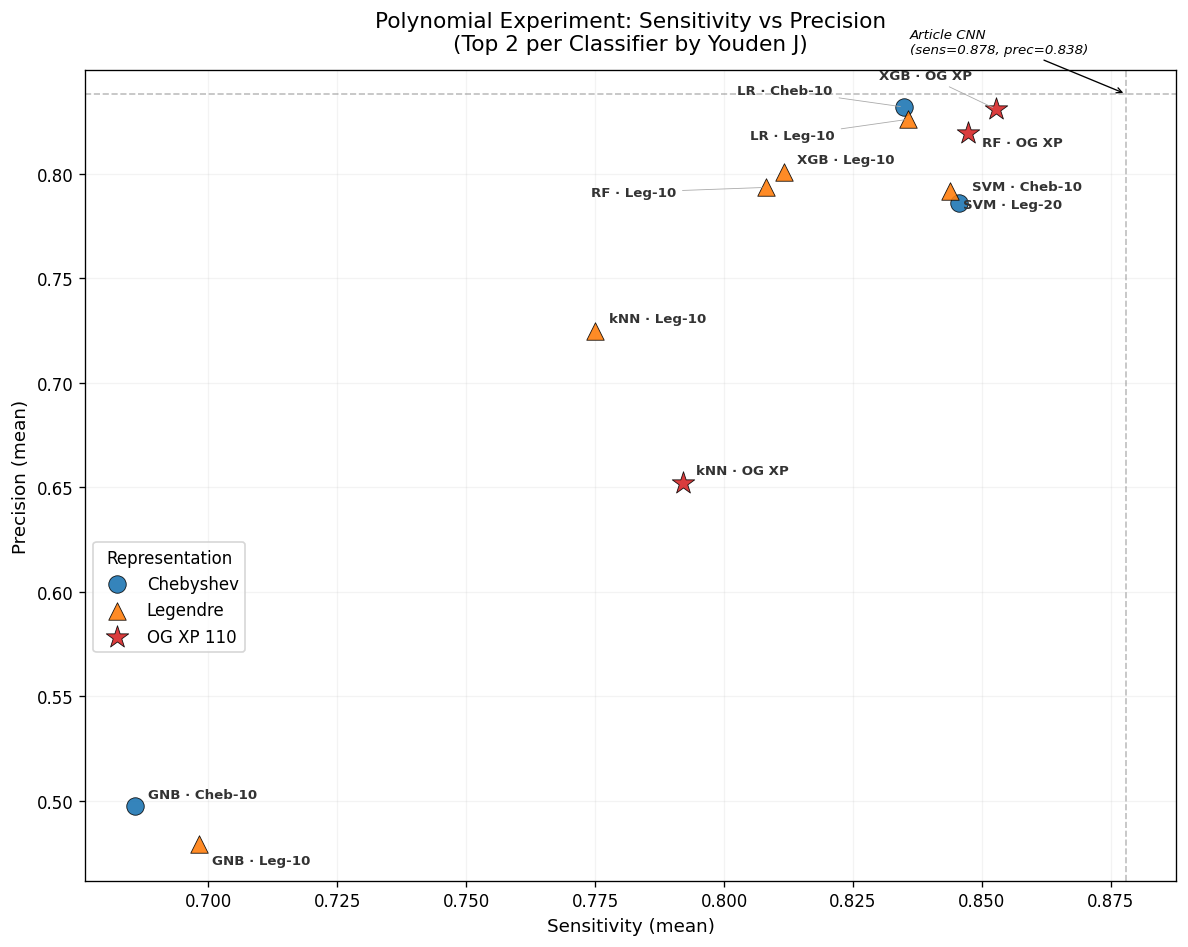


Top 2 per classifier by Youden J (precision ≥ 0.3):
        label  youden_j_mean  sensitivity_mean  precision_mean  roc_auc_mean
  XGB · OG XP         0.8090            0.8527          0.8309        0.9527
   RF · OG XP         0.8005            0.8473          0.8195        0.9495
 LR · Cheb-10         0.7927            0.8348          0.8319        0.9215
  LR · Leg-10         0.7918            0.8357          0.8260        0.9201
 SVM · Leg-20         0.7885            0.8438          0.7917        0.9245
SVM · Cheb-10         0.7877            0.8455          0.7859        0.9373
 XGB · Leg-10         0.7613            0.8116          0.8010        0.9192
  RF · Leg-10         0.7539            0.8080          0.7934        0.9194
 kNN · Leg-10         0.7016            0.7750          0.7249        0.8988
  kNN · OG XP         0.6862            0.7920          0.6522        0.9028
GNB · Cheb-10         0.5128            0.6857          0.4976        0.8232
 GNB · Leg-10         0

In [17]:
top2 = (
    df_viable
    .sort_values("youden_j_mean", ascending=False)
    .groupby("classifier")
    .head(2)
    .copy()
)

basis_labels = {
    "og_xp": "OG XP 110",
    "chebyshev": "Chebyshev",
    "hermite": "Hermite",
    "laguerre": "Laguerre",
    "legendre": "Legendre",
}
top2["basis_label"] = top2["basis"].map(basis_labels)

clf_short = {
    "LogisticRegression": "LR", "SVM_RBF": "SVM",
    "RandomForest": "RF", "XGBoost": "XGB",
    "GaussianNB": "GNB", "kNN": "kNN",
}
repr_short = {
    "og_xp_110": "OG XP", "chebyshev_10_L2": "Cheb-10",
    "legendre_10_L2": "Leg-10", "legendre_20_L2": "Leg-20",
}
top2["label"] = top2.apply(
    lambda r: clf_short.get(r["classifier"], r["classifier"])
              + " · "
              + repr_short.get(r["representation"], r["representation"]),
    axis=1,
)
top2["rank"] = top2.groupby("classifier").cumcount() + 1

colors = {"OG XP 110": "#d62728", "Chebyshev": "#1f77b4", "Legendre": "#ff7f0e",
          "Hermite": "#2ca02c", "Laguerre": "#9467bd"}
markers = {"OG XP 110": "*", "Chebyshev": "o", "Legendre": "^",
           "Hermite": "s", "Laguerre": "D"}
sizes = {"OG XP 110": 200, "Chebyshev": 110, "Legendre": 110,
         "Hermite": 110, "Laguerre": 110}

fig, ax = plt.subplots(figsize=(10, 8))

for bl, grp in top2.groupby("basis_label"):
    ax.scatter(grp["sensitivity_mean"], grp["precision_mean"],
               marker=markers[bl], color=colors[bl], label=bl,
               s=sizes[bl], alpha=0.9, edgecolors="k", linewidths=0.5, zorder=3)

label_positions = {
    ("XGB", "og_xp_110"):              (-70, 18),
    ("RF",  "og_xp_110"):              (8, -8),
    ("LR",  "chebyshev_10_L2"):        (-100, 8),
    ("LR",  "legendre_10_L2"):         (-95, -12),
    ("SVM", "chebyshev_10_L2"):        (8, 8),
    ("SVM", "legendre_20_L2"):         (8, -10),
    ("XGB", "legendre_10_L2"):         (8, 5),
    ("RF",  "legendre_10_L2"):         (-105, -5),
    ("kNN", "legendre_10_L2"):         (8, 5),
    ("kNN", "og_xp_110"):              (8, 5),
    ("GNB", "chebyshev_10_L2"):        (8, 5),
    ("GNB", "legendre_10_L2"):         (8, -12),
}

for _, row in top2.iterrows():
    cshort = clf_short.get(row["classifier"], row["classifier"])
    key = (cshort, row["representation"])
    ox, oy = label_positions.get(key, (8, 5))
    ax.annotate(
        row["label"], (row["sensitivity_mean"], row["precision_mean"]),
        fontsize=8, fontweight="bold", color="#333",
        xytext=(ox, oy), textcoords="offset points",
        arrowprops=dict(arrowstyle="-", lw=0.5, color="#aaa") if abs(ox) > 30 else None,
    )

ax.axhline(ART_PREC, ls="--", lw=1, color="gray", alpha=0.5)
ax.axvline(ART_SENS, ls="--", lw=1, color="gray", alpha=0.5)
ax.annotate(f"Article CNN\n(sens={ART_SENS}, prec={ART_PREC})",
            xy=(ART_SENS, ART_PREC), fontsize=8, style="italic",
            xytext=(-130, 25), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", lw=0.8))

ax.set_xlabel("Sensitivity (mean)", fontsize=11)
ax.set_ylabel("Precision (mean)", fontsize=11)
ax.set_title("Polynomial Experiment: Sensitivity vs Precision\n(Top 2 per Classifier by Youden J)",
             fontsize=13, pad=12)
ax.legend(title="Representation", loc="center left", fontsize=10, title_fontsize=10,
          bbox_to_anchor=(0.0, 0.35))
ax.grid(True, alpha=0.15)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "poly_sens_vs_prec.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTop 2 per classifier by Youden J (precision ≥ {MIN_PRECISION}):")
print(top2[["label", "youden_j_mean", "sensitivity_mean", "precision_mean", "roc_auc_mean"]]
      .sort_values("youden_j_mean", ascending=False)
      .to_string(index=False, float_format="%.4f"))